Given your setup:

```text id="dataset_layout"
Google Drive
│
└── FloorPlanDataset/
    │
    ├── train/
    │   ├── images/
    │   └── labels/
    │
    └── data.yaml
```

and you only have a **train** folder uploaded to Google Drive, the notebook should:

1. Mount Google Drive
2. Read images from `train/images`
3. Split into Train / Valid / Test
4. Create YOLO folder structure
5. Generate updated `data.yaml`
6. Train YOLOv5
7. Evaluate
8. Export model

# Cell 1: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Cell 2: Define Dataset Location

Update this path according to your Drive:

In [2]:
DATASET_ROOT = "/content/drive/MyDrive/Colab Notebooks/dnw"

Expected:
```text
dnw/
│
├── train/
│   ├── images/
│   └── labels/
│
└── data.yaml
```

# Cell 3: Clone YOLOv5

In [3]:
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 18366, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 18366 (delta 35), reused 17 (delta 17), pack-reused 18305 (from 2)
Receiving objects: 100% (18366/18366), 17.52 MiB | 19.33 MiB/s, done.
Resolving deltas: 100% (12480/12480), done.


In [6]:
%cd yolov5

/content/yolov5


In [8]:
!pip install -qr requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 14.8 MB/s eta 0:00:00


# Cell 4: Verify GPU

In [9]:
import torch

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


# Cell 5: Create Train/Valid/Test Split

In [10]:
import os
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

ROOT = DATASET_ROOT

SOURCE_IMAGES = f"{ROOT}/train/images"
SOURCE_LABELS = f"{ROOT}/train/labels"

SPLIT_ROOT = f"{ROOT}/split_dataset"

# Create folders

In [11]:
for split in ["train", "valid", "test"]:
    os.makedirs(f"{SPLIT_ROOT}/{split}/images", exist_ok=True)
    os.makedirs(f"{SPLIT_ROOT}/{split}/labels", exist_ok=True)

# Read images

In [12]:
image_files = []

for ext in ["*.jpg","*.jpeg","*.png"]:
    image_files.extend(
        list(Path(SOURCE_IMAGES).glob(ext))
    )

print("Total Images:", len(image_files))

Total Images: 49


# 80 / 10 / 10

In [13]:
train_imgs, temp_imgs = train_test_split(
    image_files,
    test_size=0.20,
    random_state=42
)

val_imgs, test_imgs = train_test_split(
    temp_imgs,
    test_size=0.50,
    random_state=42
)

splits = {
    "train": train_imgs,
    "valid": val_imgs,
    "test": test_imgs
}

for split_name, files in splits.items():

    for img_path in files:

        stem = img_path.stem

        label_path = Path(
            SOURCE_LABELS
        ) / f"{stem}.txt"

        shutil.copy2(
            img_path,
            f"{SPLIT_ROOT}/{split_name}/images/{img_path.name}"
        )

        if label_path.exists():

            shutil.copy2(
                label_path,
                f"{SPLIT_ROOT}/{split_name}/labels/{stem}.txt"
            )

print("Split Completed")

Split Completed


# Cell 6: Verify Split

In [14]:
for split in ["train","valid","test"]:

    img_count = len(
        os.listdir(
            f"{SPLIT_ROOT}/{split}/images"
        )
    )

    lbl_count = len(
        os.listdir(
            f"{SPLIT_ROOT}/{split}/labels"
        )
    )

    print(split)
    print("Images:", img_count)
    print("Labels:", lbl_count)
    print("-"*30)

train
Images: 39
Labels: 39
------------------------------
valid
Images: 5
Labels: 5
------------------------------
test
Images: 5
Labels: 5
------------------------------


# Cell 7: Generate data.yaml

Using your uploaded classes:

In [15]:
import yaml

data_yaml = {
    "train": f"{SPLIT_ROOT}/train/images",
    "val": f"{SPLIT_ROOT}/valid/images",
    "test": f"{SPLIT_ROOT}/test/images",
    "nc": 11,
    "names": [
        "bed",
        "dining_table",
        "door",
        "entry_door",
        "kitchen_counter",
        "north",
        "sofa",
        "storage",
        "tv",
        "wc",
        "window"
    ]
}

In [16]:
yaml_path = f"{SPLIT_ROOT}/data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f)

print("Created:", yaml_path)

Created: /content/drive/MyDrive/Colab Notebooks/dnw/split_dataset/data.yaml


# Cell 8: Validate Dataset

Optional sanity check:

In [19]:
import glob

print("Train:",
      len(glob.glob(f"{SPLIT_ROOT}/train/images/*")))

print("Valid:",
      len(glob.glob(f"{SPLIT_ROOT}/valid/images/*")))

print("Test:",
      len(glob.glob(f"{SPLIT_ROOT}/test/images/*")))

Train: 39
Valid: 5
Test: 5


# Cell 9: Start Training

In [23]:
!python train.py \
--img 1024 \
--batch-size 8 \
--epochs 200 \
--data "$yaml_path" \
--weights yolov5m.pt \
--cache ram \
--patience 30 \
--name floorplan_detector

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: vasant-s-rajadhyax (vasant-rajadhyax) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
train: weights=yolov5m.pt, cfg=, data=/content/drive/MyDrive/Colab Notebooks/dnw/split_dataset/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=200, batch_size=8, imgsz=1024, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=floorplan_detector, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=30, freeze=[0], save_period=-1, seed=0,

# Cell 10: View Training Results

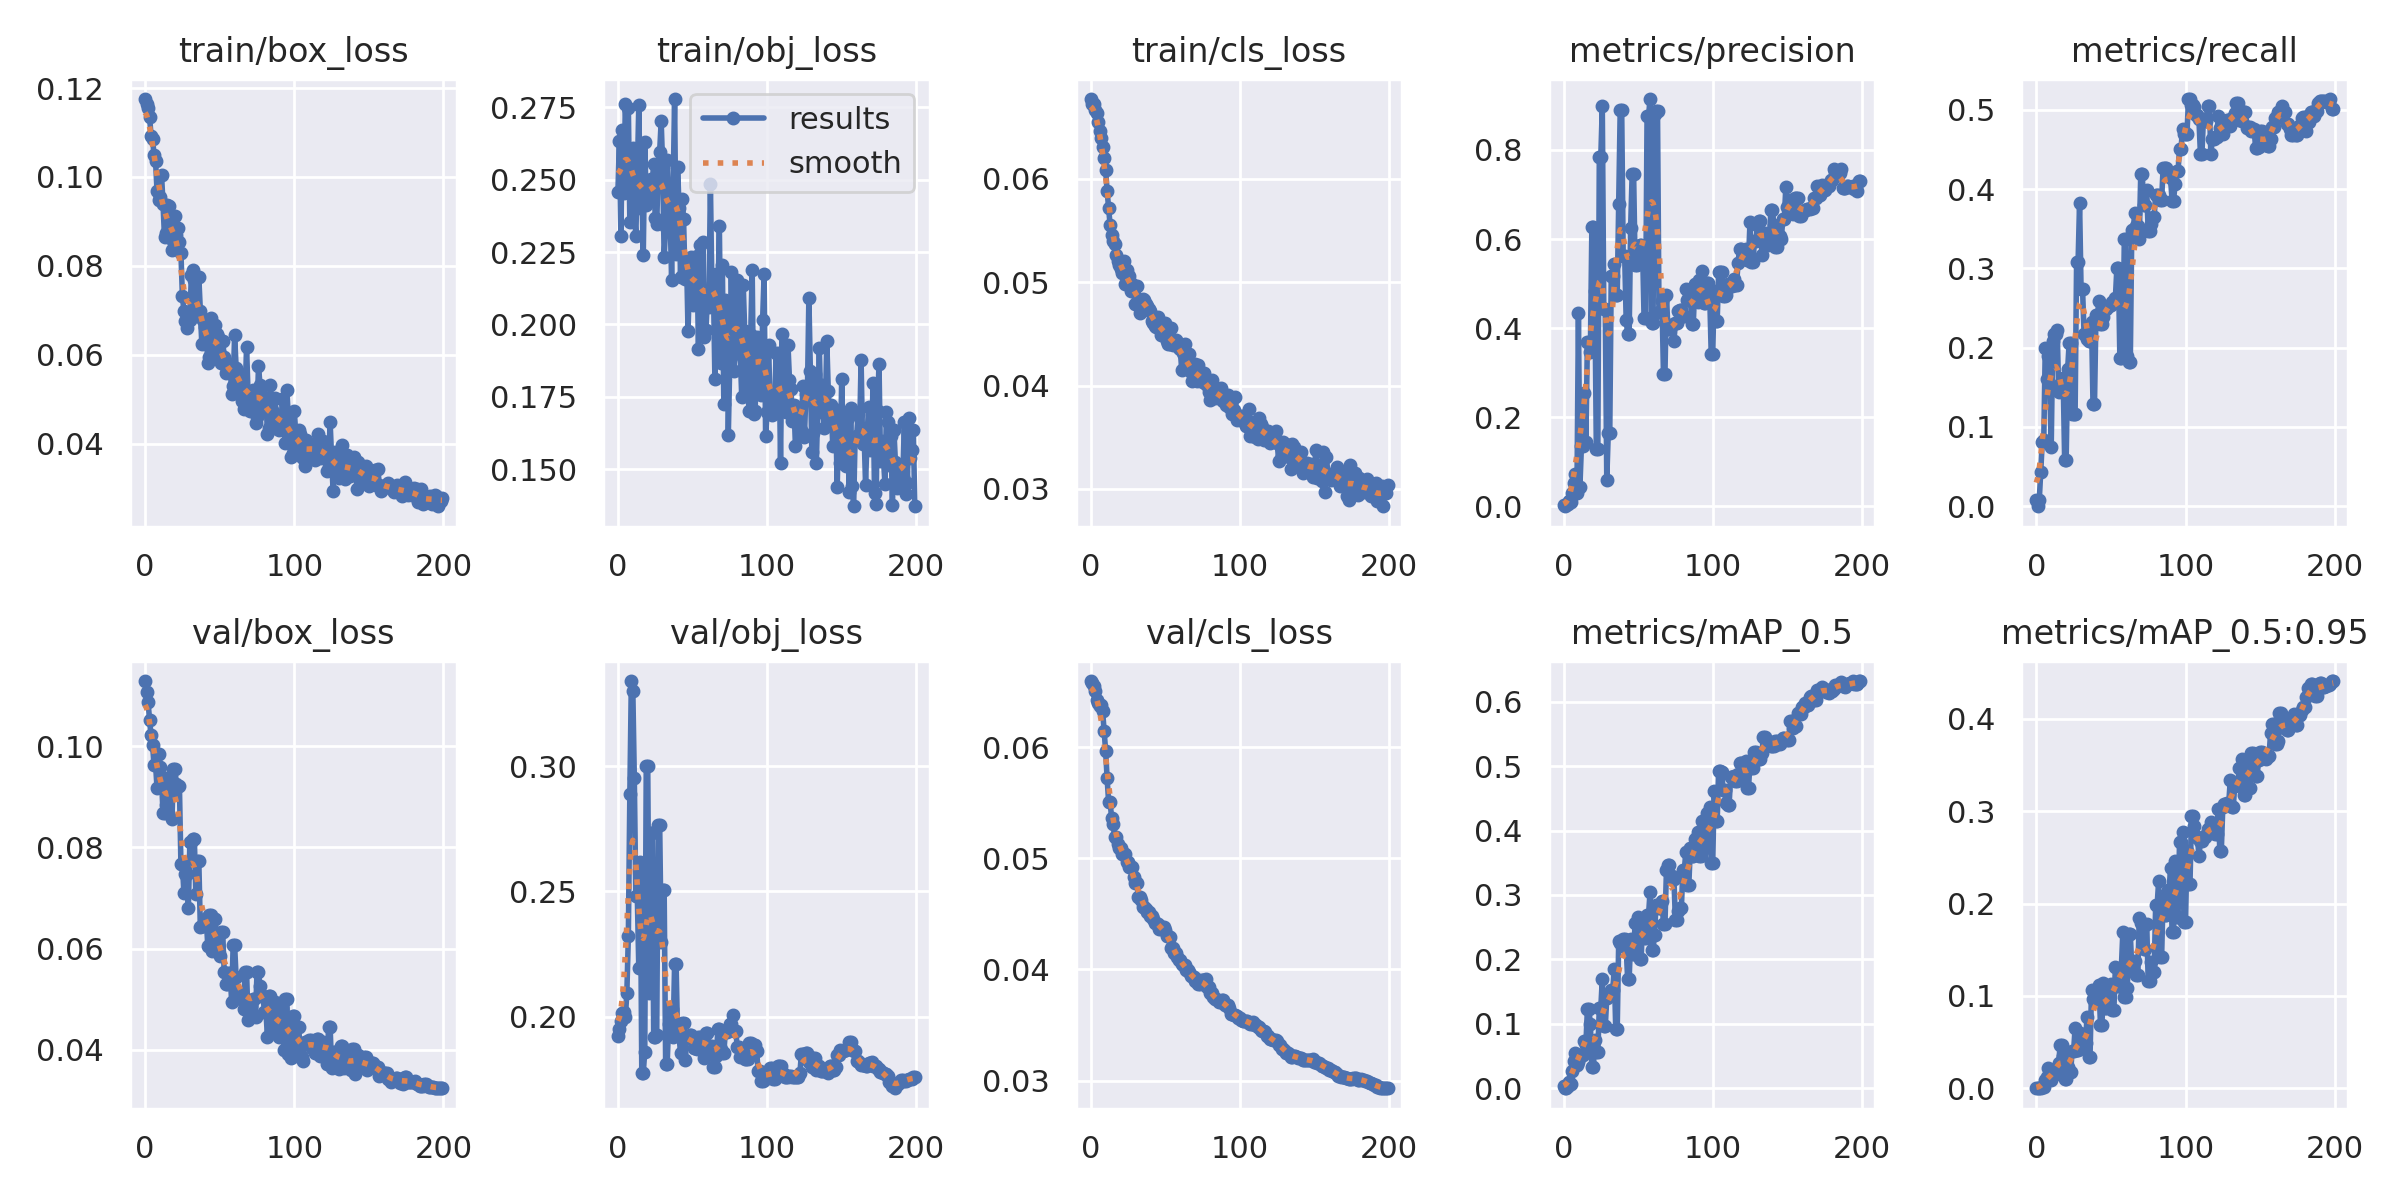

In [24]:
from IPython.display import Image

Image(
    "runs/train/floorplan_detector/results.png"
)

# Cell 11: Evaluate Best Model

In [27]:
!ls runs/train

floorplan_detector


In [28]:
!ls runs/train/floorplan_detector/weights

best.pt  last.pt


In [29]:
!python val.py \
--weights runs/train/floorplan_detector/weights/best.pt \
--data "$yaml_path" \
--imgsz 1024

val: data=/content/drive/MyDrive/Colab Notebooks/dnw/split_dataset/data.yaml, weights=['runs/train/floorplan_detector/weights/best.pt'], batch_size=32, imgsz=1024, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-504-g59fd5786 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 212 layers, 20893344 parameters, 0 gradients, 48.0 GFLOPs
val: Scanning /content/drive/MyDrive/Colab Notebooks/dnw/split_dataset/valid/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% 5/5 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 1/1 [00:01<00:00,  1.09s/it]
                   all          5        144      0.728      0.501      0.632      0.443
                   bed     

# Cell 12: Run Prediction

In [31]:
TEST_IMAGE = "/content/drive/MyDrive/Colab Notebooks/dnw/split_dataset/test/images"

!python detect.py \
--weights "$BEST_MODEL" \
--source "$TEST_IMAGE" \
--imgsz 1024 \
--conf-thres 0.25

detect: weights=[''], source=, data=data/coco128.yaml, imgsz=[1024, 1024], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-504-g59fd5786 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Traceback (most recent call last):
  File "/content/yolov5/detect.py", line 444, in <module>
    main(opt)
  File "/content/yolov5/detect.py", line 439, in main
    run(**vars(opt))
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/content/yolov5/detect.py", line 174, in run
    model = DetectMultiBackend(weights, de

# Cell 13: Show Predictions

In [ ]:
from glob import glob
from IPython.display import Image

preds = glob("runs/detect/exp/*.jpg")

Image(preds[0])

# Cell 14: Export Model

### ONNX

In [ ]:
!python export.py \
--weights runs/train/floorplan_detector/weights/best.pt \
--include onnx

### TensorRT

In [ ]:
!python export.py \
--weights runs/train/floorplan_detector/weights/best.pt \
--include engine

## Recommended Training Settings for Your Floor Plan Dataset

| Parameter        | Value   |
| ---------------- | ------- |
| Model            | YOLOv5m |
| Image Size       | 1024    |
| Batch Size       | 8       |
| Epochs           | 200     |
| Patience         | 30      |
| Cache            | True    |
| Train Split      | 80%     |
| Validation Split | 10%     |
| Test Split       | 10%     |

If you have **fewer than 500 floor plans**, I would modify the notebook to use **90% train / 10% validation only** and skip the test split until the final model evaluation. This generally improves detector quality when data is limited.


In [2]:
from PIL import Image

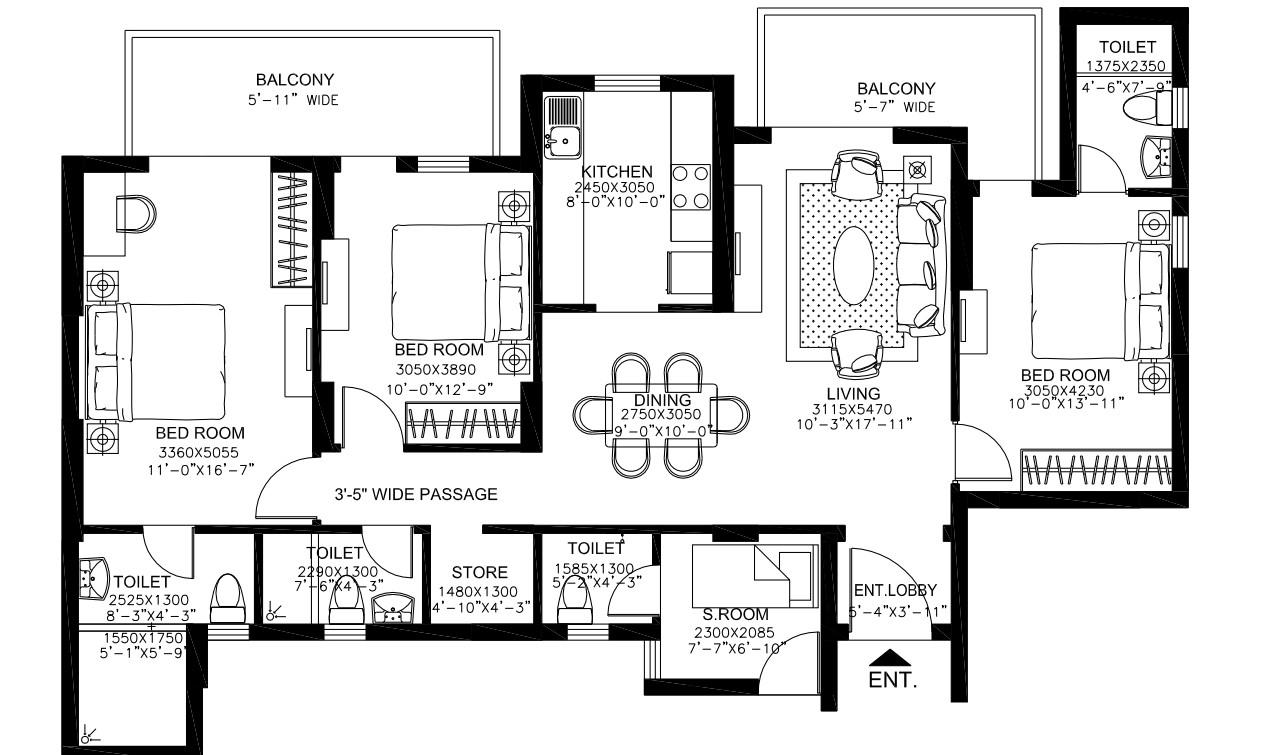

In [3]:
img = Image.open("/home/pamya/Python/ML_Projects/doorandwindow_yolov5/train/images/3_jpg.rf.c6eed044af41a3661cc981955790657d.jpg")
display(img)